# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## Sinais e Sistemas - Lista 3a

### Lista 3a e exercícios em sala da aula



In [5]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

### $3^a$ Lista de Exercícios


####  $1^a$ Questão:

Para cada um dos sinais periódicos mostrados na Figura P6.1-1, encontre a série trigonométrica compacta de Fourier e esboce os espectros de amplitude e fase. Se os termos seno ou cosseno estiverem ausentes na série de Fourier, explique por quê.


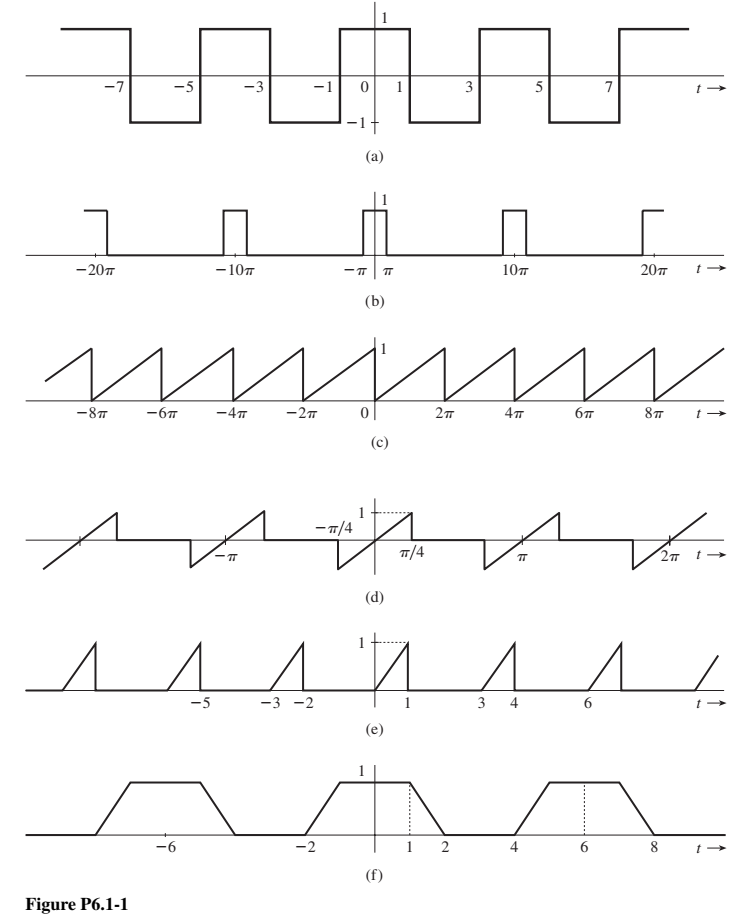

**Comentários preliminares:** o exercício pede a ``série trigonométrica compacta de Fourier``, que é dada por


$$
f(t)=C_0+\sum_{n=1}^{\infty} C_n \cos \left(n \omega_0 t+\theta_n\right),
$$

onde os coeficientes $C_0$ e $C_n$ são derivados da ``forma trigonométrica da série de Fourier``
$$
f(t)=a_0+\sum_{n=1}^{\infty} a_n \cos n \omega_0 t+b_n \operatorname{sen} n \omega_0 t,
$$

através das relações 

\begin{aligned}
C_0 & =a_0 \\
C_n & =\sqrt{a_n^2+b_n^2} \\
\theta_n & =\tan ^{-1}\left(\frac{-b_n}{a_n}\right)
\end{aligned}

e, levando-se em conta que os coeficientes $a_0$, $a_n$ e $b_n$ são dados por

\begin{aligned}
& a_0=\frac{1}{T_0} \int_{T_0} f(t) d t \\
& a_n=\frac{2}{T_0} \int_{T_0} f(t) \cos n \omega_0 t d t \\
& b_n=\frac{2}{T_0} \int_{T_0} f(t) \operatorname{sen} n \omega_0 t d t
\end{aligned}





**(a) Solução:**


Note que:

 - $T_0=4$ e, portanto, $\omega_0=\frac{2 \pi}{T_0}=\frac{\pi}{2};$ 

 - Devido à simetria par, todos os termos $b_n$ são nulos;
 
 - Como o termo $a_0$ é o valor médio de $f(t)$ em um período, temos que $a_0 = 0$

Por uma questão de simetria e simplicidade, vamos determinar $a_n$ considerando o intervalo de integração $[0,2]$ e multiplicando a integral por 2:

In [37]:
t = symbols('t')
n = symbols('n', integer = True, positive = True)
T0 = 4
w0 = pi/2

an = 2*(2/T0)*(integrate(1*cos(n*w0*t),(t,0,1)) +  integrate(-1*cos(n*w0*t),(t,1,2)))
display(Math('a_n = ' + latex(an)))

<IPython.core.display.Math object>

Portanto, a série de Fourier (em sua forma trigonométrica), é dada por 

$$
f(t)=\frac{4}{\pi}\left(\cos \frac{\pi t}{2}-\frac{1}{3} \cos \frac{3 \pi t}{2}+\frac{1}{5} \cos \frac{5 \pi t}{2}-\frac{1}{7} \cos \frac{7 \pi t}{2}+\cdots\right),
$$



Alternativamente, podemos calcular a série trigonométrica de Fourier através da função ``fourier_series``

In [38]:
#from sympy.abc import t
f = sym.Piecewise((-1, (-2 <= t) & (t <=-1)), (1, (-1 <= t) & (t <=1)), (-1, (1 <= t) & (t <=2)), (0, True))
s = fourier_series(f, (t, -2, 2))
s1 = s.truncate(n = 4)
display(Math('f(t) = ' + latex(s1)))

<IPython.core.display.Math object>

Como $b_n=0,$ tem-se que  $C_n=\left|a_n\right|$ 



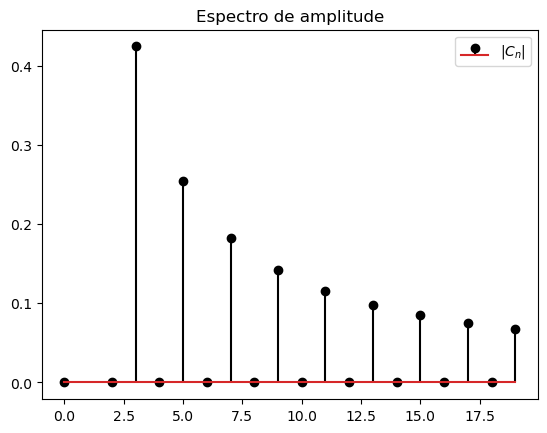

In [61]:
z = []
z1 = []
z.append(0)
z1.append(0)
for k in range(2,20):
    z.append(k)
    z1.append(abs((sin(pi*k/2)*4/(pi*k))))

plt.stem(z, z1, 'k', markerfmt='ko', label='$|C_n|$')
plt.legend()
plt.title('Espectro de amplitude')
plt.show()

Para o cálculo dos ângulos, $\theta_n$, utilizamos que $cos(\theta - \pi) = -cos(\theta)$ e, podemos reescrever

$$
f(t)=\frac{4}{\pi}\left(\cos \left(\frac{\pi t}{2}\right) + \frac{1}{3} \cos \left(\frac{3 \pi t}{2} - \pi \right)+\frac{1}{5} \cos \left(\frac{5 \pi t}{2} \right)+\frac{1}{7} \cos \left( \frac{7 \pi t}{2} -\pi \right)+\cdots\right),
$$




ambos mostrados na Fig. S6.1-1a. A frequência correspondente $\omega$ é facilmente calculada como $\omega_0 n=\frac{\pi n}{2}$.

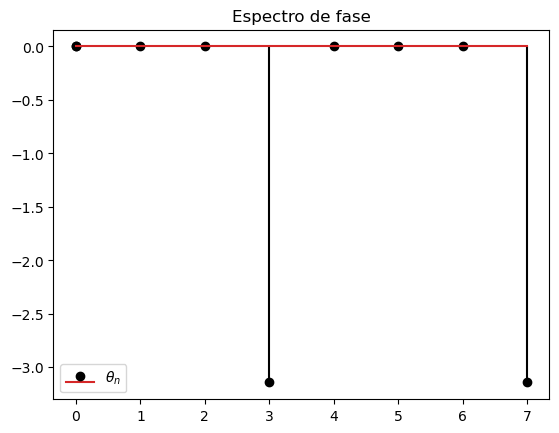

In [65]:
z = [0,1,2,3,4,5,6,7]
z1 = [0,0,0,-pi,0,0,0,-pi]
z.append(0)
z1.append(0)
plt.stem(z, z1, 'k', markerfmt='ko', label='$\\theta_n$')
plt.legend()
plt.title('Espectro de fase')
plt.show()

####  $2^a$ Questão:


Determine a série trigonométrica compacta de Fourier para os sinais periódicos mostrados na Fig. 6.6. Trace seus espectros de amplitude e fase. Permita que $C_n$ assuma valores negativos se $b_n=0$, de tal forma que o espectro de fase possa ser eliminado. 


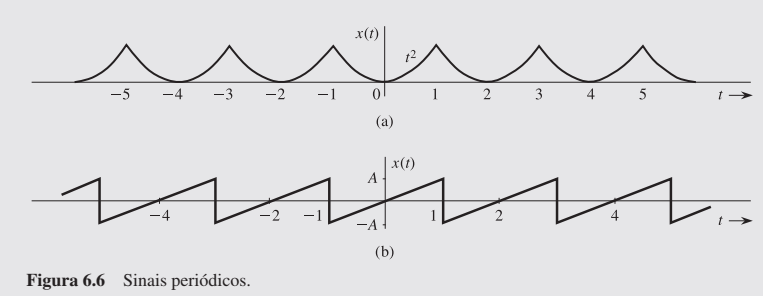

Para o sinal da Figura 6.6a, temos que



####  $3^a$ Questão:

 - 3.1
 
(a) Verifique o teorema de Parseval para essa série de Fourier para o sinal da Fig. 6.6a, dado que
$$
\sum_{n=1}^{\infty} \frac{1}{n^4}=\frac{\pi^4}{90}
$$

(b) Se $x(t)$ for aproximada pelos $N$ primeiros temos da série, obtenha $N$ tal que a potência do sinal de erro seja menor do que $1 \%$ de $P_x$.

 - 3.2 

(c) Verifique o teorema de Parseval para a série de Fourier do sinal periódico da Fig. 6.6b, dado que
$$
\sum_{n=1}^{\infty} \frac{1}{n^2}=\frac{\pi^2}{6}
$$

(d) Se $x(t)$ for aproximada pelos $N$ primeiros temos da série, obtenha $N$ tal que a potência do sinal de erro seja menor do que $10 \%$ de $P_x$.

####  $4^a$ Questão:

O espectro exponencial de Fourier de um certo sinal periódico $x(t)$ está mostrado na Fig. 6.13. Determine e trace o espectro trigonométrico de Fourier de $x(t)$ por inspeção da Fig. 6.13. Escreva, agora, a série trigonométrica (compacta) de Fourier de $x(t)$.

####  $5^a$ Questão:

Determine a série exponencial de Fourier e trace o espectro de Fourier $D_n$ correspondente em função de $\omega$ para o seno retificado (onda completa) mostrado na Fig. 6.14.

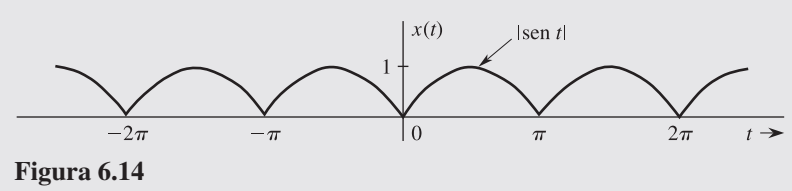